In [1]:
import os

import json

import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql.functions import size, col,when, regexp_extract
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType, StringType, StructType, StructField, DoubleType, TimestampType

import pyspark.ml.classification

In [2]:
spark = SparkSession.builder \
    .appName("STEAD_pipeline") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "17g") \
    .config("spark.executor.instances", 7) \
    .config("spark.sql.parquet.enableVectorizedReader", "false")\
    .getOrCreate()

In [3]:
# get Spark UI url
# print(f"Spark UI: {spark.sparkContext.uiWebUrl}")

In [4]:
parquet_path = "/expanse/lustre/scratch/epak/temp_project/stead_version4"
#df = spark.read.parquet(os.path.join(os.environ['HOME'],parquet_path))

In [5]:
df_sample = spark.read.parquet(parquet_path).sample(withReplacement=False, fraction=0.05, seed=42)

In [6]:
df_eq = df_sample.filter(F.col("trace_category") == 'earthquake_local')

In [7]:
# Drop unhelpful predictor variables as found from covariance matrix
df = df_eq.drop('source_distance_deg','receiver_latitude','trace_category')

In [8]:
waveforms = ['waveform_Z','waveform_N','waveform_E']

In [9]:
df_sample = df.dropDuplicates(["source_id", "network_code", "receiver_code"])

# Random Forest Regressor Model

Predict `s_arrival_sample` using waveform data stratified into `'waveform_Z'`,`'waveform_N'`,`'waveform_E']`

## 7 executors 20 trees, max depth: 5 (using 5% of the data) (no caching)

In [10]:
import time
from pyspark.sql import functions as F
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.functions import array_to_vector

print(f"-> number of rows: {df_sample.count()} (not accounting for waveform dimensionality)")

# Start global timer
global_start_rf1 = time.time()

# ==========================================
# 1. PRE-PROCESSING
# ==========================================
print("Setting up Pre-Processing graph for RF1...")

downsample_time_rf1 = time.time()
# Downsample from 100 Hz to 20 Hz
df_rf1 = df_sample.withColumn(
    "wave_N_down", F.expr("filter(waveform_N, (x, i) -> i % 5 == 0)")
).withColumn(
    "wave_Z_down", F.expr("filter(waveform_Z, (x, i) -> i % 5 == 0)")
).withColumn(
    "wave_E_down", F.expr("filter(waveform_E, (x, i) -> i % 5 == 0)")
)
df_ml_rf1 = df_rf1.withColumn("label", (F.col("s_arrival_sample") / 5).cast("double"))
df_ml_rf1.count()

print(f"-> Waveform Frequency downsampling runtime: {time.time() - downsample_time_rf1:.4f} seconds.")

vectorize_time_rf1 = time.time()

df_ml_rf1 = (
    df_ml_rf1.withColumn("vec_N", array_to_vector(F.col("wave_N_down")))
      .withColumn("vec_Z", array_to_vector(F.col("wave_Z_down")))
      .withColumn("vec_E", array_to_vector(F.col("wave_E_down")))
)
df_ml_rf1.count()

print(f"-> vectorizing waveform data: {time.time() - vectorize_time_rf1:.4f} seconds.")

df_ml_rf1 = df_ml_rf1.select("label", "vec_N", "vec_Z", "vec_E")

# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================
print("\nDefining Train/Test split for RF1...")

train_data_rf1, test_data_rf1 = df_ml_rf1.randomSplit([0.8, 0.2], seed=42)

# ==========================================
# 3. PIPELINE STAGES
# ==========================================
assembler_rf1 = VectorAssembler(
    inputCols=["vec_N", "vec_E", "vec_Z"],
    outputCol="features"
)

# Random Forest Regressor 1
rf_estimator_rf1 = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    numTrees=20,                  # Number of trees to train
    maxDepth=5,                   # Max depth of each tree
    featureSubsetStrategy="auto", # Randomly samples features per split
    seed=42
)

pipeline_rf1 = Pipeline(stages=[assembler_rf1, rf_estimator_rf1])

# ==========================================
# 4. TRAINING & EVALUATION
# ==========================================
print("\nTraining PySpark Random Forest Regressor Model 1...")
train_start_rf1 = time.time()

model_rf1 = pipeline_rf1.fit(train_data_rf1)

print(f"-> Model 1 Training Complete! Time taken: {time.time() - train_start_rf1:.2f} seconds.")

print("\nMaking predictions on the test set and evaluating Model 1...")
eval_start_rf1 = time.time()

predictions_rf1 = model_rf1.transform(test_data_rf1)

evaluator_rf1 = RegressionEvaluator(
    predictionCol="prediction",
    labelCol="label",
    metricName="rmse"
)

rmse_rf1 = evaluator_rf1.evaluate(predictions_rf1)

print(f"-> Test Evaluation Complete! Time taken: {time.time() - eval_start_rf1:.2f} seconds.")

# ==========================================
# EXTRA: Calculate Train RMSE
# ==========================================
print("\nMaking predictions on the train set to calculate Train RMSE...")
train_eval_start_rf1 = time.time()

# 1. Transform the training data using the fitted model
train_predictions_rf1 = model_rf1.transform(train_data_rf1)

# 2. Evaluate using the exact same evaluator you already built
train_rmse_rf1 = evaluator_rf1.evaluate(train_predictions_rf1)

print(f"-> Train Evaluation Complete! Time taken: {time.time() - train_eval_start_rf1:.2f} seconds.")

# ==========================================
# 5. FINAL RESULTS (Updated)
# ==========================================
print(f"\n==========================================")
print(f"Model 1 (Trees: 20, Depth: 5) Train RMSE: {train_rmse_rf1:.2f} samples")
print(f"Model 1 (Trees: 20, Depth: 5) Test RMSE:  {rmse_rf1:.2f} samples")
print(f"Total Pipeline Execution Time: {time.time() - global_start_rf1:.2f} seconds.")
print(f"==========================================")

-> number of rows: 51404 (not accounting for waveform dimensionality)
Setting up Pre-Processing graph for RF1...
-> Waveform Frequency downsampling runtime: 2.8344 seconds.
-> vectorizing waveform data: 3.4628 seconds.

Defining Train/Test split for RF1...

Training PySpark Random Forest Regressor Model 1...
-> Model 1 Training Complete! Time taken: 450.98 seconds.

Making predictions on the test set and evaluating Model 1...
-> Test Evaluation Complete! Time taken: 370.58 seconds.

Making predictions on the train set to calculate Train RMSE...
-> Train Evaluation Complete! Time taken: 371.85 seconds.

Model 1 (Trees: 20, Depth: 5) Train RMSE: 84.71 samples
Model 1 (Trees: 20, Depth: 5) Test RMSE:  87.47 samples
Total Pipeline Execution Time: 1199.75 seconds.


## S-Wave Test Predictions vs Actual Values Visualizations for Random Forest Model with 20 Trees, Max Depth: 5

Extracting predictions to Pandas for plotting Model 1...


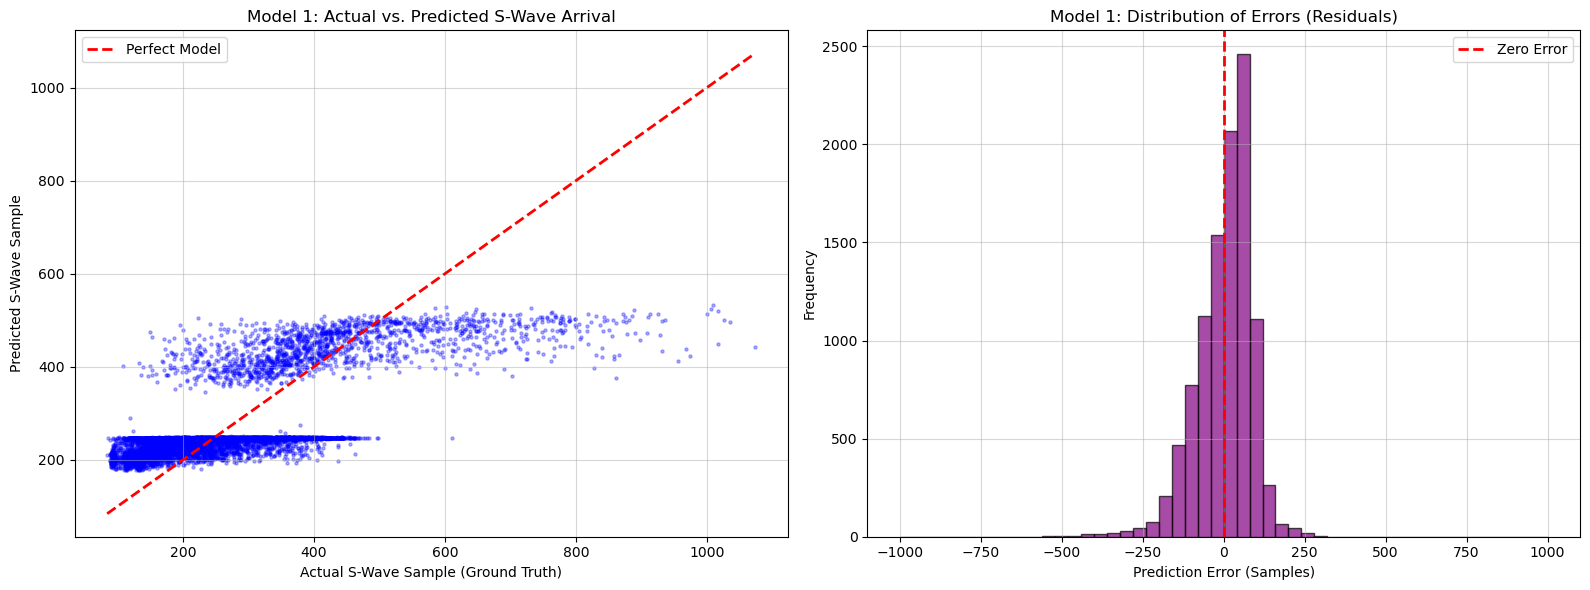

In [18]:
import matplotlib.pyplot as plt
import numpy as np

print("Extracting predictions to Pandas for plotting Model 1...")
# Select ONLY the label and prediction columns to prevent Out-Of-Memory crashes
results_df_rf1 = predictions_rf1.select("label", "prediction").toPandas()

# Calculate residuals (Error = Predicted - Actual)
results_df_rf1['residual'] = results_df_rf1['prediction'] - results_df_rf1['label']

# ==========================================
# Plot 1: Actual vs. Predicted
# ==========================================
fig_rf1, ax_rf1 = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
ax_rf1[0].scatter(results_df_rf1['label'], results_df_rf1['prediction'], alpha=0.3, color='blue', s=5)

# Draw the "Perfect Prediction" diagonal line
min_val_rf1 = min(results_df_rf1['label'].min(), results_df_rf1['prediction'].min())
max_val_rf1 = max(results_df_rf1['label'].max(), results_df_rf1['prediction'].max())
ax_rf1[0].plot([min_val_rf1, max_val_rf1], [min_val_rf1, max_val_rf1], color='red', linestyle='--', linewidth=2, label="Perfect Model")

ax_rf1[0].set_title("Model 1: Actual vs. Predicted S-Wave Arrival")
ax_rf1[0].set_xlabel("Actual S-Wave Sample (Ground Truth)")
ax_rf1[0].set_ylabel("Predicted S-Wave Sample")
ax_rf1[0].legend()
ax_rf1[0].grid(True, alpha=0.5)

# ==========================================
# Plot 2: Residuals Histogram (Error Distribution)
# ==========================================
# We limit the x-axis to clip out insane outliers so the graph is readable
ax_rf1[1].hist(results_df_rf1['residual'], bins=50, range=(-1000, 1000), color='purple', edgecolor='black', alpha=0.7)

ax_rf1[1].axvline(0, color='red', linestyle='dashed', linewidth=2, label="Zero Error")
ax_rf1[1].set_title("Model 1: Distribution of Errors (Residuals)")
ax_rf1[1].set_xlabel("Prediction Error (Samples)")
ax_rf1[1].set_ylabel("Frequency")
ax_rf1[1].legend()
ax_rf1[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

## 7 executors 40 trees, max depth: 3 (using 5% of the data) (no caching)

In [11]:
import time
from pyspark.sql import functions as F
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.functions import array_to_vector

print(f"-> number of rows: {df_sample.count()} (not accounting for waveform dimensionality)")

# Start global timer
global_start = time.time()

# ==========================================
# 1. PRE-PROCESSING
# ==========================================
print("Setting up Pre-Processing graph...")

downsample_time = time.time()
# Downsample from 100 Hz to 20 Hz
df = df_sample.withColumn(
    "wave_N_down", F.expr("filter(waveform_N, (x, i) -> i % 5 == 0)")
).withColumn(
    "wave_Z_down", F.expr("filter(waveform_Z, (x, i) -> i % 5 == 0)")
).withColumn(
    "wave_E_down", F.expr("filter(waveform_E, (x, i) -> i % 5 == 0)")
)
df_ml = df.withColumn("label", (F.col("s_arrival_sample") / 5).cast("double"))
df_ml.count()

print(f"-> Waveform Frequency downsampling runtime: {time.time() - downsample_time:.4f} seconds.")

vectorize_time = time.time()

df_ml = (
    df_ml.withColumn("vec_N", array_to_vector(F.col("wave_N_down")))
      .withColumn("vec_Z", array_to_vector(F.col("wave_Z_down")))
      .withColumn("vec_E", array_to_vector(F.col("wave_E_down")))
)
df_ml.count()

print(f"-> vectorizing waveform data: {time.time() - vectorize_time:.4f} seconds.")

df_ml = df_ml.select("label", "vec_N", "vec_Z", "vec_E")

# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================
print("\nDefining Train/Test split...")

train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)

# ==========================================
# 3. PIPELINE STAGES
# ==========================================
assembler = VectorAssembler(
    inputCols=["vec_N", "vec_E", "vec_Z"],
    outputCol="features"
)

# Random Forest Regressor
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    numTrees=40,                  # Number of trees to train (can increase if memory allows)
    maxDepth=3,                   # Max depth of each tree
    featureSubsetStrategy="auto", # Randomly samples features per split
    seed=42
)

pipeline = Pipeline(stages=[assembler, rf])

# ==========================================
# 4. TRAINING & EVALUATION
# ==========================================
print("\nTraining PySpark Random Forest Regressor Model...")
train_start = time.time()

model = pipeline.fit(train_data)

print(f"-> Model Training Complete! Time taken: {time.time() - train_start:.2f} seconds.")

print("\nMaking predictions on the test set and evaluating...")
eval_start = time.time()

predictions = model.transform(test_data)

evaluator = RegressionEvaluator(
    predictionCol="prediction",
    labelCol="label",
    metricName="rmse"
)

rmse = evaluator.evaluate(predictions)

print(f"-> Evaluation Complete! Time taken: {time.time() - eval_start:.2f} seconds.")

# ==========================================
# 5. FINAL RESULTS
# ==========================================
print(f"\n==========================================")
print(f"Test RMSE: {rmse:.2f} samples")
print(f"Total Pipeline Execution Time: {time.time() - global_start:.2f} seconds.")
print(f"==========================================")

-> number of rows: 51404 (not accounting for waveform dimensionality)
Setting up Pre-Processing graph...
-> Waveform Frequency downsampling runtime: 2.8584 seconds.
-> vectorizing waveform data: 3.4865 seconds.

Defining Train/Test split...

Training PySpark Random Forest Regressor Model...
-> Model Training Complete! Time taken: 470.61 seconds.

Making predictions on the test set and evaluating...
-> Evaluation Complete! Time taken: 389.26 seconds.

Test RMSE: 93.55 samples
Total Pipeline Execution Time: 866.26 seconds.


## S-Wave Metric Visualizations for Random Forest Model with 40 Trees, Max Depth: 3

Extracting predictions to Pandas for plotting...


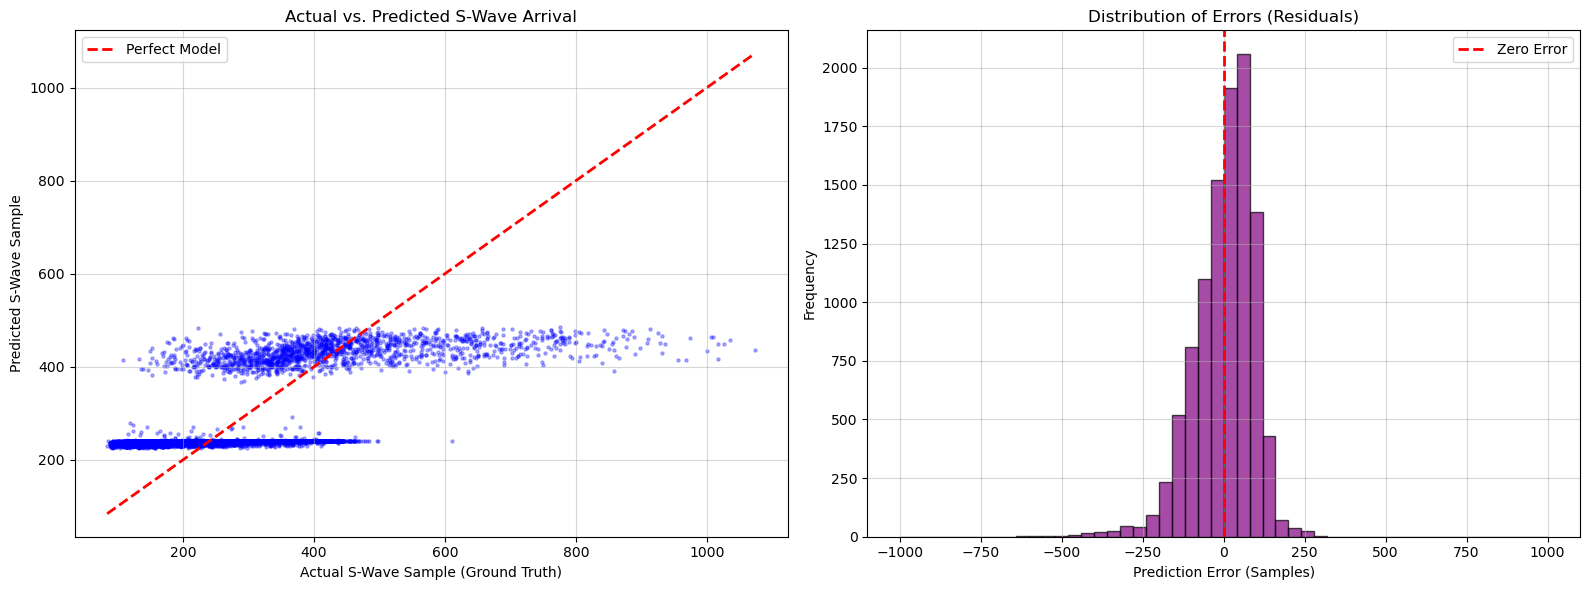

In [14]:
import matplotlib.pyplot as plt
import numpy as np

print("Extracting predictions to Pandas for plotting...")
# Select ONLY the label and prediction columns to prevent Out-Of-Memory crashes
results_df = predictions.select("label", "prediction").toPandas()

# Calculate residuals (Error = Predicted - Actual)
results_df['residual'] = results_df['prediction'] - results_df['label']

# ==========================================
# Plot 1: Actual vs. Predicted
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
ax[0].scatter(results_df['label'], results_df['prediction'], alpha=0.3, color='blue', s=5)

# Draw the "Perfect Prediction" diagonal line
min_val = min(results_df['label'].min(), results_df['prediction'].min())
max_val = max(results_df['label'].max(), results_df['prediction'].max())
ax[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label="Perfect Model")

ax[0].set_title("Actual vs. Predicted S-Wave Arrival")
ax[0].set_xlabel("Actual S-Wave Sample (Ground Truth)")
ax[0].set_ylabel("Predicted S-Wave Sample")
ax[0].legend()
ax[0].grid(True, alpha=0.5)

# ==========================================
# Plot 2: Residuals Histogram (Error Distribution)
# ==========================================
# We limit the x-axis to clip out insane outliers so the graph is readable
ax[1].hist(results_df['residual'], bins=50, range=(-1000, 1000), color='purple', edgecolor='black', alpha=0.7)

ax[1].axvline(0, color='red', linestyle='dashed', linewidth=2, label="Zero Error")
ax[1].set_title("Distribution of Errors (Residuals)")
ax[1].set_xlabel("Prediction Error (Samples)")
ax[1].set_ylabel("Frequency")
ax[1].legend()
ax[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()